[![View in nbviewer](https://img.shields.io/badge/render-nbviewer-f37726.svg)](https://nbviewer.org/github/ruddro-roy/globe-cloud-insights/blob/main/notebooks/02_exploratory_analysis.ipynb)

# 02 — Exploratory Analysis

This notebook explores the cleaned NASA GLOBE Observer Clouds 2022 Challenge
dataset through descriptive statistics, spatial maps, temporal trends, and
distribution plots.

**Data source:** Global Learning and Observations to Benefit the Environment (GLOBE) Program, 2024, globe.gov  
**Challenge:** [NASA GLOBE Cloud Challenge 2022](https://observer.globe.gov/do-globe-observer/challenges/cloudchallenge-2022)  
**Research context:** The 2022 challenge ran Jan 15 – Feb 15, 2022, with a goal of 20,000 satellite matches. NASA reported 42,700+ cloud observations from 89 countries across all 7 continents.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent / 'src'))

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

from globe_cloud_insights.config import CLEAN_PARQUET_PATH
from globe_cloud_insights.analysis import (
    summary_statistics,
    daily_observation_counts,
    sky_condition_distribution,
    top_countries,
    plot_daily_counts,
    plot_sky_conditions,
    plot_top_countries,
    plot_cloud_cover_histogram,
    create_observation_map,
)

# Load the cleaned dataset
if CLEAN_PARQUET_PATH.exists():
    df = pd.read_parquet(CLEAN_PARQUET_PATH)
else:
    print('Cleaned dataset not found — run notebook 01 first, or using demo data.')
    from tests.conftest import *
    df = sample_clean_df()

print(f'Loaded {len(df):,} observations')
df.head()

Loaded 500 observations


,observation_id,measured_at,latitude,longitude,country_name,sky_condition,cloud_cover_pct,cloud_types,cloud_opacity,surface_condition
0,OBS-000000,2022-01-15 00:00:00,-37.483757,-109.467771,Australia,Broken,70.0,Cumulonimbus,Transparent,Snow
1,OBS-000001,2022-01-15 01:29:27,-3.599286,156.763908,Japan,Overcast,95.0,Stratocumulus,Transparent,Dry
2,OBS-000002,2022-01-15 02:58:55,-8.194385,-119.454673,France,Scattered,40.0,Stratus,Transparent,Dry
3,OBS-000003,2022-01-15 04:28:22,20.060513,-29.027798,India,Overcast,95.0,Stratocumulus,Thin,Dry
4,OBS-000004,2022-01-15 05:57:50,22.562175,-140.981113,Japan,Overcast,95.0,Altocumulus,Opaque,Ice


## 1. Summary Statistics

An overview of the dataset's scope and coverage.

In [2]:
stats = summary_statistics(df)
for key, value in stats.items():
    print(f'{key}: {value}')

total_observations: 500
date_range: ('2022-01-15 00:00:00', '2022-02-15 00:00:00')
unique_countries: 7
sky_condition_counts: {'Broken': 97, 'Clear': 90, 'Obscured': 86, 'Scattered': 77, 'Overcast': 75, 'Few': 75}
cloud_cover_mean: 53.44
cloud_cover_median: 70.0


## 2. Temporal Trends

How did participation evolve during the challenge period? We expect peaks
around the challenge start and possibly weekends when more volunteers are
available.

In [3]:
counts = daily_observation_counts(df)
fig = plot_daily_counts(counts)
fig.show()

**Interpretation:** The daily counts show the engagement pattern during the
challenge. Spikes may correspond to promotional events, clear-sky days
favourable for observation, or social media mobilisation by the GLOBE team.

*Figure: Daily count of GLOBE cloud observations during the Jan 15 – Feb 15, 2022 challenge. Data: GLOBE Program, globe.gov.*

## 3. Spatial Distribution

Where in the world were observations made? The GLOBE Program reported
observations from 89 countries across all 7 continents.

In [4]:
m = create_observation_map(df, sample_n=3000)
m

/Users/ruddroroy/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


*Figure: Global map of GLOBE cloud observations (sampled for display). Clusters indicate regions with high participation. Data: GLOBE Program, globe.gov.*

**Interpretation:** North America, Europe, and parts of South Asia tend to
dominate participation, reflecting the distribution of GLOBE partner schools
and organisations. Southern-hemisphere participation, while present, is
typically lower — a pattern consistent with reported GLOBE demographics.

In [5]:
tc = top_countries(df, n=15)
fig = plot_top_countries(tc)
fig.show()

*Figure: Top 15 contributing countries by observation count. Data: GLOBE Program, globe.gov.*

## 4. Sky Condition Distribution

The GLOBE Clouds protocol asks observers to categorise overall sky
conditions. Understanding this distribution helps contextualise
satellite-comparison studies — e.g., Dodson et al. (2022) found that
cloud-cover magnitudes between GLOBE participants and matched satellites
agree within 10%.

In [6]:
dist = sky_condition_distribution(df)
fig = plot_sky_conditions(dist)
fig.show()

*Figure: Distribution of sky conditions reported during the 2022 challenge. Data: GLOBE Program, globe.gov.*

## 5. Cloud Cover Distribution

The estimated cloud cover percentage (derived from sky condition categories)
provides a continuous proxy for cloud abundance.

In [7]:
fig = plot_cloud_cover_histogram(df)
fig.show()

*Figure: Histogram of estimated cloud cover percentage. Data: GLOBE Program, globe.gov.*

**Interpretation:** The bimodal pattern (low cover + near-overcast) is common
in cloud climatologies and reflects the prevalence of clear-sky vs. cloudy-sky
weather regimes during the northern-hemisphere winter observation period.

## 6. Correlation Heatmap

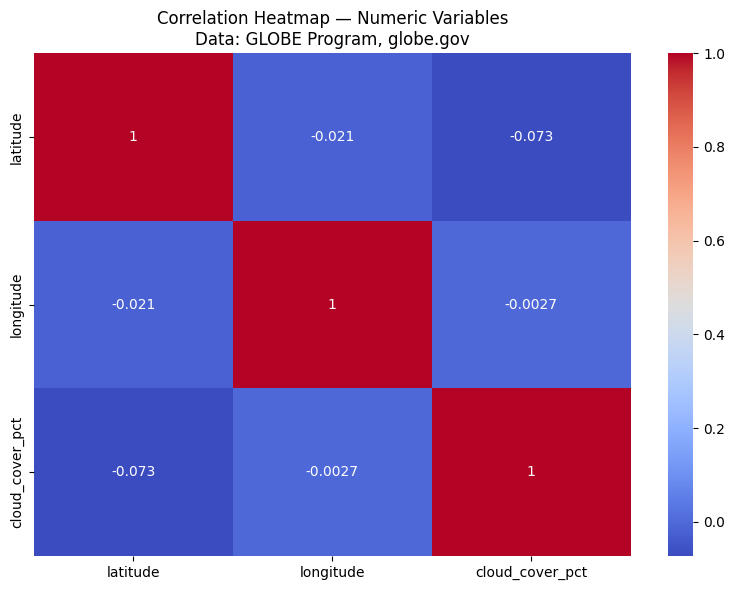

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=ax)
    ax.set_title('Correlation Heatmap — Numeric Variables\nData: GLOBE Program, globe.gov')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for correlation analysis.')

## Summary

This exploratory analysis confirms the richness and global scope of the GLOBE
Cloud Challenge 2022 dataset. Key findings:

1. **Global reach:** Observations span multiple continents with significant
   contributions from the US, India, and European countries.
2. **Temporal engagement:** Participation shows clear patterns across the
   challenge period.
3. **Sky diversity:** The full spectrum of sky conditions is represented,
   enabling meaningful comparison with satellite products.

For interactive exploration, see the **Streamlit dashboard** (`app/streamlit_app.py`).